# Audio Feature Extraction
Goal: Practice generating some time-domain features and generating waveforms

Tasks include:
-	Load audio
-	Visualize waveforms
-	Extract and visualize time-domain features:
  -  amplitude envelope
  -  root mean square energy
  -  zero-crossing rate
-	Apply the fourier transform and extract and visualize frequency-domain features:
  - MFCCs 0-13
  - Spectral centroid and bandwidth

Audio used:
- Chicken egg song recorded by K Rubio in 2025 from Florence

Date last updated: 4/30/2026
Author: Kay Rubio

In [1]:
# Check python version for compatibility with librosa, 3.12.8 is OK in 2025
!python3 --version

Python 3.12.8


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display
import IPython.display as ipd
import soundfile as sf
import os
import sys
from pathlib import Path

In [2]:
# have to modify where notebook looks for imports so it looks in the project root, not the notebook folder
os.getcwd()
sys.path.append(str(Path().resolve().parent))
print(sys.path)

['/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python312.zip', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12', '/Users/dontfreakout/.pyenv/versions/3.12.8/lib/python3.12/lib-dynload', '', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis/.venv/lib/python3.12/site-packages', '/Users/dontfreakout/Documents/Education (reduced)/Computer_Science/Data_Science/Audio Signal Processing/Potential Projects/2026_Audio_Signal_Analysis/audio-signal-analysis']


In [3]:
from utils.time_domain_utils import (
  plot_waveform,
  plot_waveform_with_line,
  amplitude_envelope,
)
from utils.frequency_domain_utils import (
  plot_spectrogram,
  short_time_fourier_transform,
  plot_spectral_centroid,
  plot_mfccs,
)

## Load audio and explore audio

In [4]:
filename = 'chicken.wav'
filepath = f'../data/audio/{filename}'
# Librosa.load automatically resamples at sr=22050
file, sr = librosa.load(filepath)

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Chicken egg song'}, xlabel='Time (sec)', ylabel='Amplitude'>)

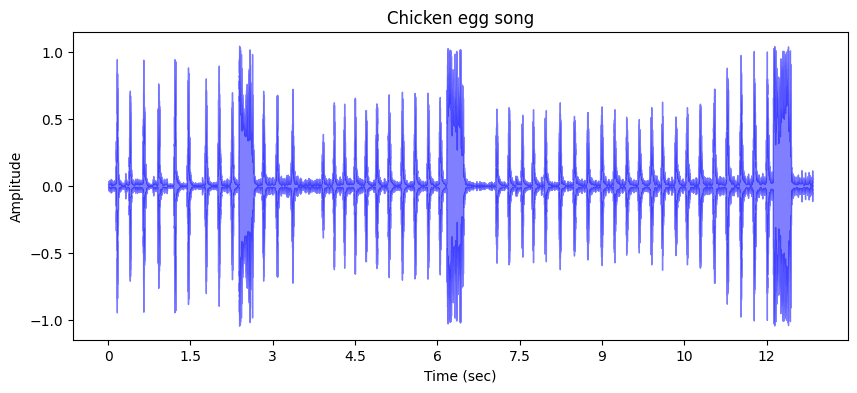

In [5]:
plot_waveform(file, 'Chicken egg song', sr)

In [6]:
output = {}
FRAME_LENGTH = 1024
HOP_LENGTH = FRAME_LENGTH//4

## Amplitude Envelope

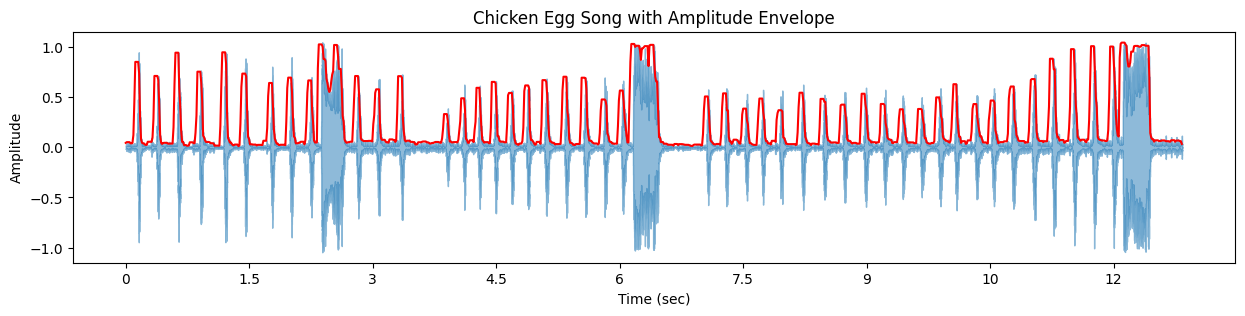

In [7]:
ae = amplitude_envelope(file, FRAME_LENGTH, HOP_LENGTH)
plot_waveform_with_line(file, "Chicken Egg Song with Amplitude Envelope", HOP_LENGTH, sr, ae, "r")

In [8]:
# Add amplitude_envelope values to output object
output['amplitude_envelope'] = ae

## Root Mean Square Energy

In [9]:
# Calculate rms as array using librosa.feature.rms and check the size of the resulting array
rms = librosa.feature.rms(y=file, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
len(rms)

1106

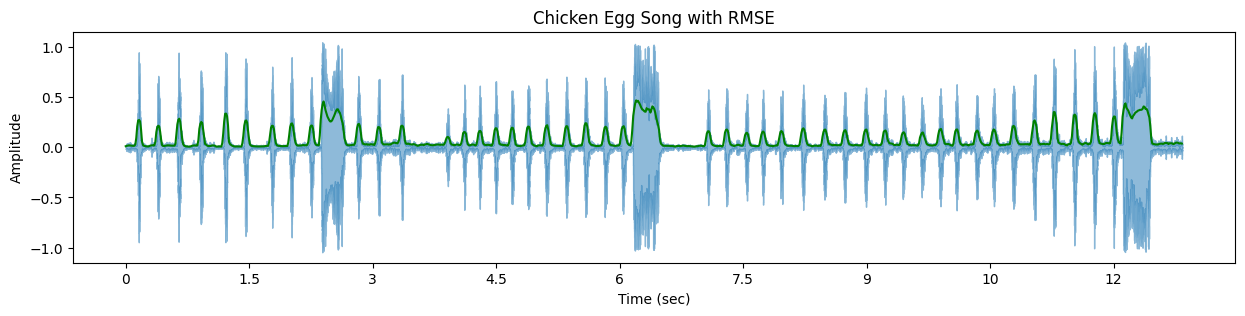

In [10]:
# Draw RMS onto waveform
plot_waveform_with_line(file, "Chicken Egg Song with RMSE", HOP_LENGTH, sr, rms, "g")

In [11]:
# Add root-mean-square energy values to output object
output['root_mean_square_energy'] = rms

## Zero-crossing rate

In [12]:
# Calculate ZCR using librosa.feature.zero_crossing_rate
zcr = librosa.feature.zero_crossing_rate(y=file, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
len(zcr)

1106

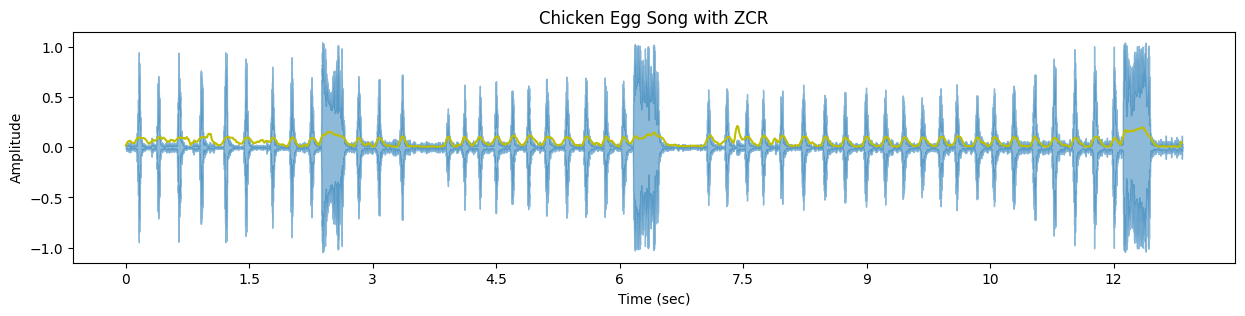

In [13]:
# Draw ZCR onto waveform
plot_waveform_with_line(file, "Chicken Egg Song with ZCR", HOP_LENGTH, sr, zcr, "y")

In [14]:
# Add ZCR values to output object
output['zero_crossing_rate'] = zcr

## Fourier Transform & Spectrogram

In [15]:
# Apply short-time fourier transform to change audio from time-domain 
# to frequency-domain
stft = short_time_fourier_transform(file, FRAME_LENGTH, HOP_LENGTH)

(<Figure size 2500x400 with 1 Axes>,
 <Axes: title={'center': 'Spectrogram'}, xlabel='Time (s)', ylabel='Frequency (Hz)'>)

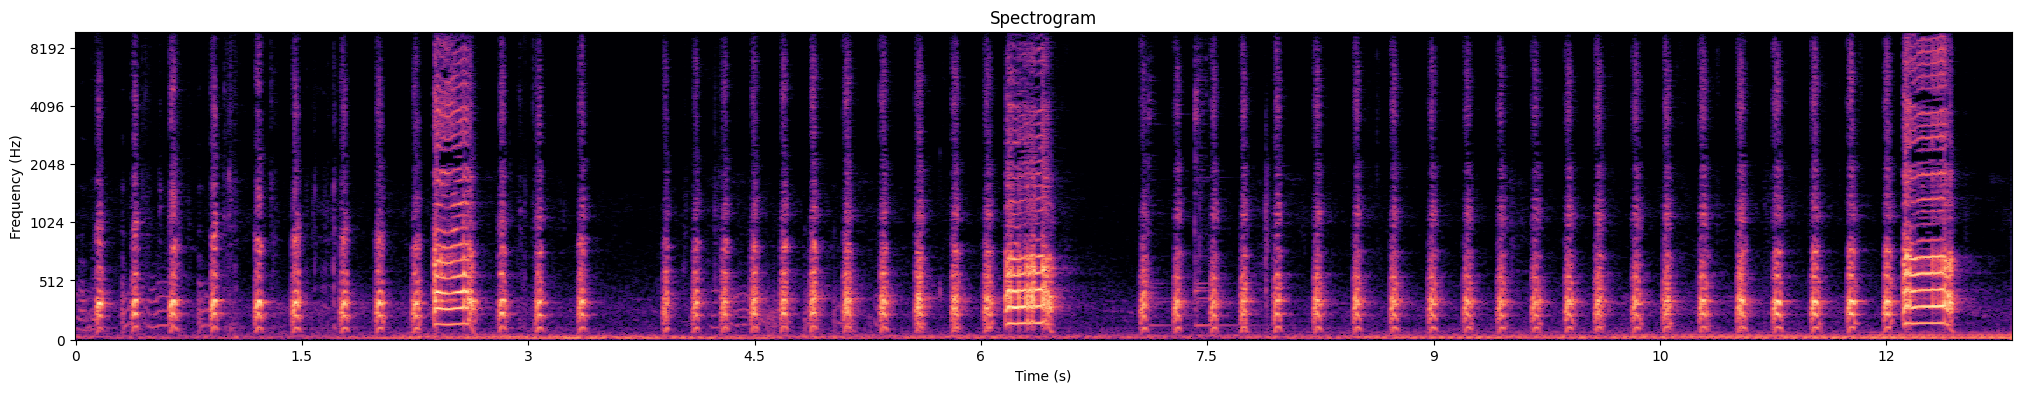

In [16]:
# Plot spectrogram, use the mel scale for frequency
plot_spectrogram(stft, sr, HOP_LENGTH, "mel", 0, 10000)

In [17]:
# Extract the first 13 MFCCs
mfccs = librosa.feature.mfcc(y=file, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH, n_mfcc=13)
mfccs.shape

(13, 1106)

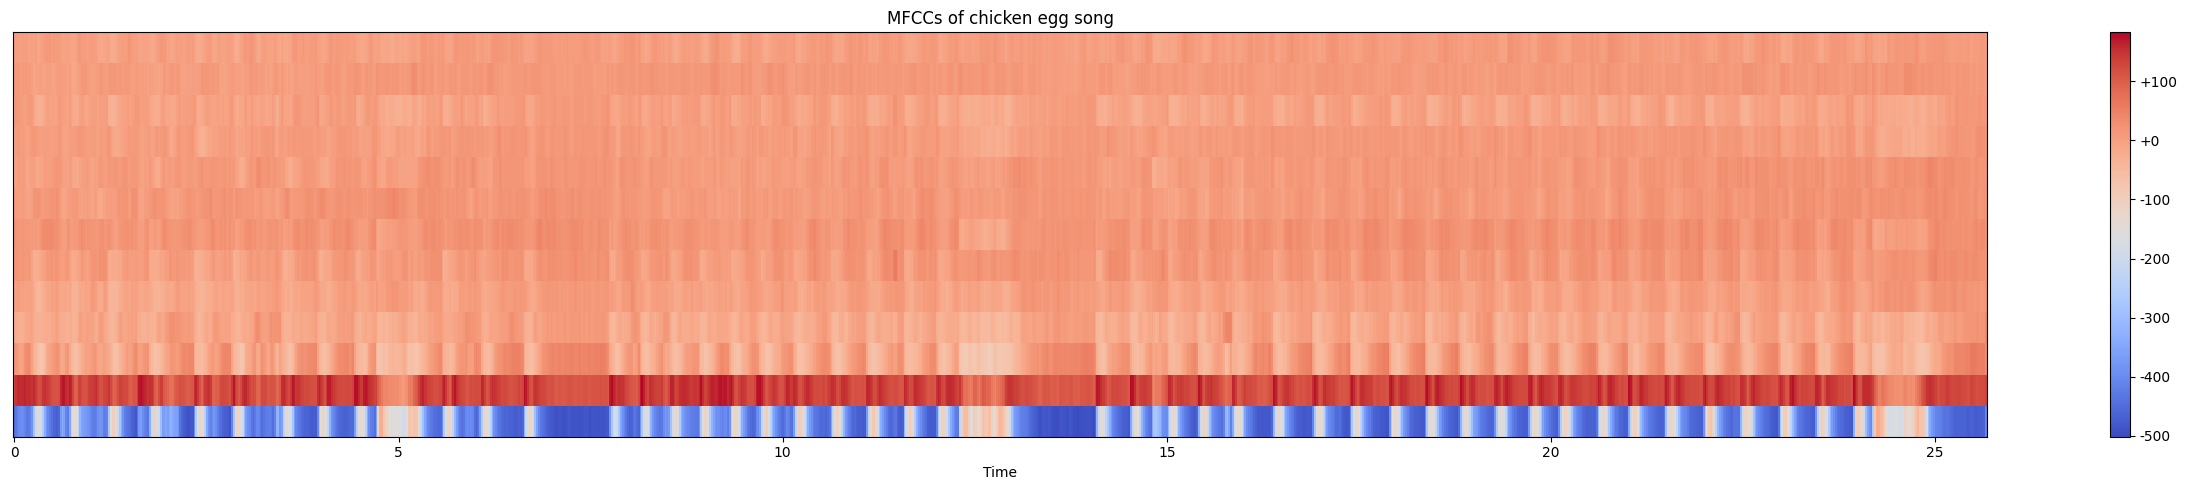

In [18]:
plot_mfccs(mfccs, sr, 'MFCCs of chicken egg song')

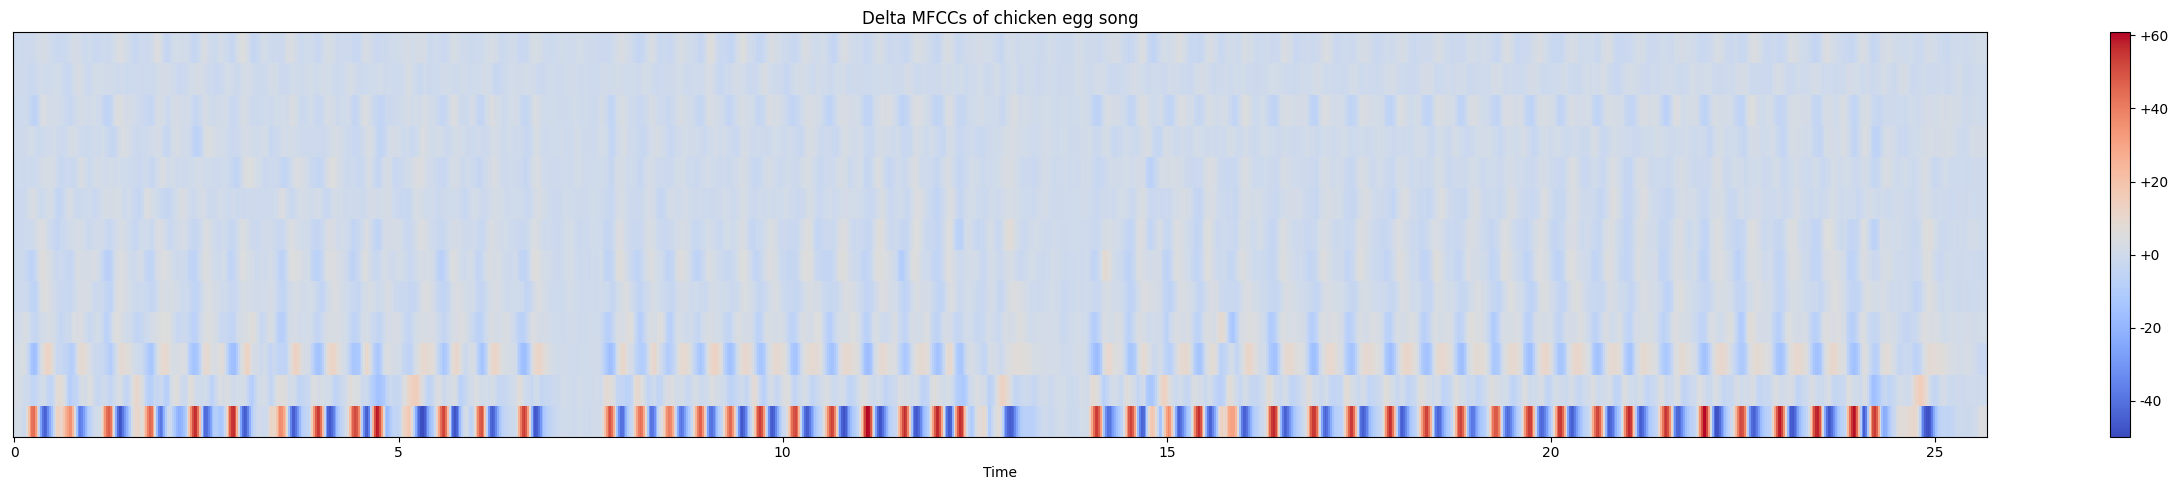

In [19]:
# Computing first MFCCs derivatives (how they change from frame-frame over time)
delta_mfccs = librosa.feature.delta(mfccs)
plot_mfccs(delta_mfccs, sr, 'Delta MFCCs of chicken egg song')

In [20]:
# Add MFCCs and MFCC delta values to output object
output['mfccs'] = mfccs
output['delta_mfccs'] = delta_mfccs

## Spectral centroid and bandwidth

In [21]:
# Calculate spectral centroid
sc = librosa.feature.spectral_centroid(y=file, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

In [22]:
# Calculate spectral bandwidth
sban = librosa.feature.spectral_bandwidth(y=file, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]

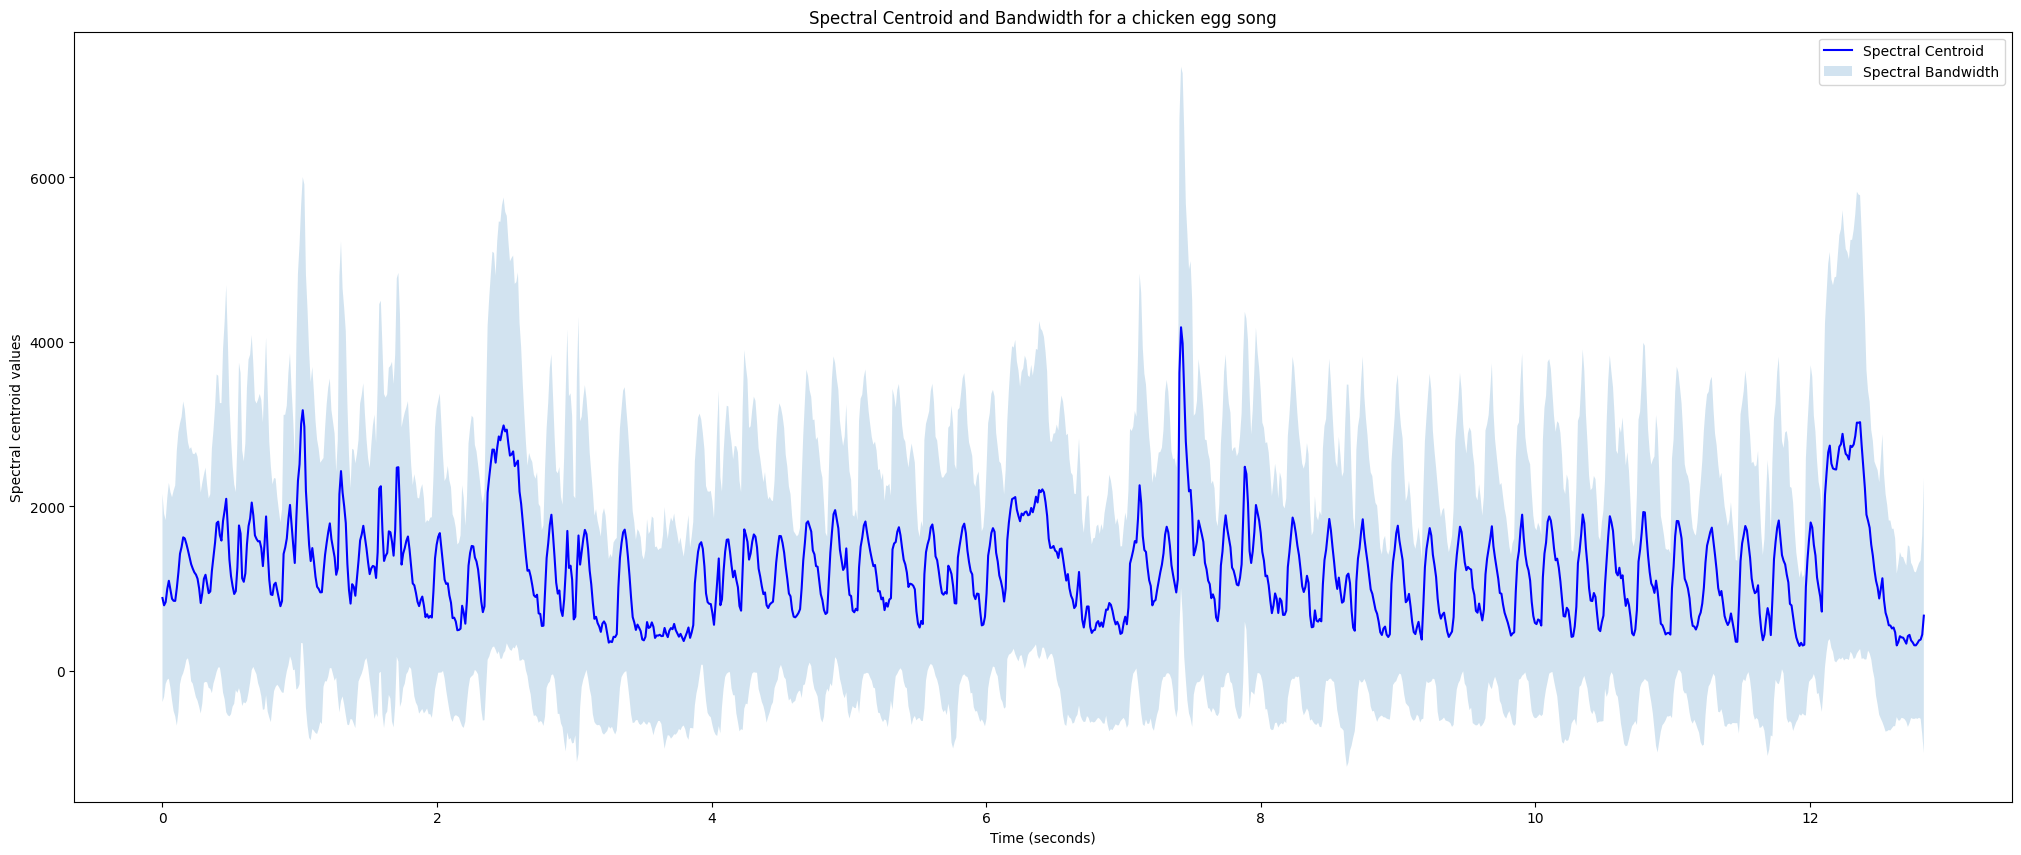

In [23]:
# Plot spectral centroid and bandwidth
plot_spectral_centroid(sc, sban, HOP_LENGTH, 'Spectral Centroid and Bandwidth for a chicken egg song')

In [24]:
# Add spectral centroid and bandwidth values to output object
output['spectral_centroid'] = sc
output['spectral_bandwidth'] = sban